# Bihar Prohibition — Per-Capita Economic Growth (Notebook 07)

**Method:** Synthetic Control Method (Abadie, Diamond & Hainmueller 2010)
**Outcome:** NSDP per-capita YoY growth rate (%)
**Treated unit:** Bihar
**Treatment date:** April 2016 (alcohol prohibition)
**Donor pool:** 13 Indian states (Telangana excluded — bifurcation 2014)

---

## Research Question

> **Did Bihar's 2016 prohibition cause a change in per-capita NSDP growth
> relative to comparable Indian states?**

This is the third outcome in the Bihar prohibition study, complementing:
- **Notebook 05** — Road accident deaths (primary safety outcome)
- **Notebook 09** — Own tax revenue (fiscal outcome via BSTS)

Per-capita NSDP growth is the cleanest economic-welfare measure available
in the panel: it reflects both the size of the economy and population
dynamics, and is computed as a year-on-year percentage change so it is
comparable across states regardless of base level.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from src.scm import SCMAnalysis
from src.plotting import (
    set_publication_style, COLOR_TREATED, COLOR_SYNTHETIC, COLOR_PLACEBO,
    treatment_line, save_fig,
)
set_publication_style()

RESULTS = Path("../results/figures")
API_RES = Path("../api/results")

## Economic Theory — Both Channels

Prohibition can affect per-capita growth through **competing channels**:

### Positive (growth-enhancing) channels
1. **Household reallocation** — Income previously spent on alcohol
   (often a regressive expenditure for poor households) shifts toward
   food, education, savings → higher human-capital accumulation.
2. **Reduced productivity loss** — Fewer alcohol-related work absences,
   accidents, and morbidity → larger effective labor supply.
3. **Public-health spillovers** — Lower hospital expenditure on
   alcohol-related trauma frees state fiscal capacity.

### Negative (growth-depressing) channels
1. **Direct excise loss** — Bihar's pre-prohibition state excise on
   alcohol was ~₹4,000 Cr/year (≈ 25% of own-tax revenue). Lost revenue
   means lost public investment.
2. **Hospitality / tourism contraction** — Hotels, restaurants, and
   tourism lose a complementary product. Documented anecdotally in news
   reports for Bihar's hospitality sector post-2016.
3. **Bootlegging / shadow economy** — Activity migrates to the informal
   sector, no longer captured in NSDP.
4. **Compliance cost** — Enforcement (police, courts, prisons) absorbs
   public resources without adding to NSDP.

**Net direction is an empirical question** — the SCM gap tells us
which side dominated for Bihar.

In [2]:
panel = pd.read_csv("../data/processed/bihar_panel.csv", parse_dates=["date"])

TREATED        = "Bihar"
TREATMENT_DATE = "2016-01-01"
OUTCOME        = "nsdp_growth_yoy"

# Same donor pool as Notebook 05 (Telangana excluded — only 2 pre-treatment obs)
DONORS = [u for u in panel["unit"].unique()
          if u not in [TREATED, "Telangana"]]

# nsdp_growth_yoy is NaN for first observation per unit (no prior year to diff
# against) and for the first 3 years (NSDP starts 2012-13 in the source). Drop
# rows where the outcome is NaN — SCM cannot match on missing target values.
panel_match = panel.dropna(subset=[OUTCOME]).copy()
print(f"Panel rows (after NaN filter on {OUTCOME}): {len(panel_match)}")
print(f"Date range : {panel_match['date'].min().year} – {panel_match['date'].max().year}")
print(f"Units      : {panel_match['unit'].nunique()}")
print(f"Donors     : {len(DONORS)}")

Panel rows (after NaN filter on nsdp_growth_yoy): 150
Date range : 2013 – 2022
Units      : 15
Donors     : 13


## 1. Pre-Treatment Sanity Check

Before fitting, confirm Bihar's pre-treatment growth lies *inside* the
donor convex hull (Abadie 2021). If Bihar were already an extreme outlier,
no convex combination of donors could match it.

In [3]:
TS = pd.to_datetime(TREATMENT_DATE)
pre = panel_match[panel_match["date"] < TS]
bihar_mean = pre[pre["unit"]==TREATED][OUTCOME].mean()
donor_means = pre[pre["unit"].isin(DONORS)].groupby("unit")[OUTCOME].mean()

print(f"Bihar pre-treatment mean growth     : {bihar_mean:5.2f} %")
print(f"Donor pool min / max pre means      : {donor_means.min():5.2f} / {donor_means.max():5.2f} %")
print(f"Inside convex hull?                  : "
      f"{'YES' if donor_means.min() <= bihar_mean <= donor_means.max() else 'NO'}")
print()
print("Donor pre-period means (sorted):")
for u, v in donor_means.sort_values().items():
    flag = "  ← Bihar between here" if v < bihar_mean and v == donor_means[donor_means < bihar_mean].max() else ""
    print(f"  {u:<20s} {v:5.2f} %{flag}")

Bihar pre-treatment mean growth     :  9.68 %
Donor pool min / max pre means      :  8.42 / 13.16 %
Inside convex hull?                  : YES

Donor pre-period means (sorted):
  Punjab                8.42 %
  Odisha                9.46 %  ← Bihar between here
  Uttar Pradesh        10.05 %
  Maharashtra          10.11 %
  Rajasthan            10.15 %
  West Bengal          10.22 %
  Andhra Pradesh       10.84 %
  Kerala               11.45 %
  Tamil Nadu           11.63 %
  Haryana              11.63 %
  Jharkhand            11.66 %
  Karnataka            12.97 %
  Madhya Pradesh       13.16 %


## 2. Fit SCM on NSDP Growth

Predictors: same Census 2011 socio-economic predictors used in Notebook 05.
Special predictors: each pre-treatment year's growth value as an explicit
matching target (Abadie et al. 2010 §IV). For growth this is less critical
than for level outcomes (growth is already detrended), but it locks the
synthetic control to Bihar's specific year-by-year trajectory.

In [4]:
PREDICTORS = ["urban_share_pct", "literacy_rate_pct"]

pre_dates = sorted([d for d in panel_match["date"].unique() if d < TS])
print(f"Pre-treatment years used as special_predictors: "
      f"{[d.year for d in pre_dates]}")

scm = SCMAnalysis(
    panel_df         = panel_match,
    treated_unit     = TREATED,
    donor_pool       = DONORS,
    predictors       = PREDICTORS,
    outcome          = OUTCOME,
    treatment_date   = TREATMENT_DATE,
    special_predictors = [(OUTCOME, [d], "mean") for d in pre_dates],
)
scm.fit()

print(f"\nDonor weights (non-zero):")
for donor, w in sorted(scm.weights_.items(), key=lambda x: -x[1]):
    if w > 0.001:
        print(f"  {donor:<20s} {w:.3f}")
print(f"\nPre-period RMSPE  : {scm.pre_rmspe():.3f} pp")
print(f"Post-period RMSPE : {scm.post_rmspe():.3f} pp")
print(f"RMSPE ratio       : {scm.rmspe_ratio():.2f}×")

Pre-treatment years used as special_predictors: [2013, 2014, 2015]



Donor weights (non-zero):
  Odisha               0.656
  Rajasthan            0.317
  Jharkhand            0.027

Pre-period RMSPE  : 0.066 pp
Post-period RMSPE : 5.565 pp
RMSPE ratio       : 83.86×


## 3. Bihar vs Synthetic Bihar — Growth Trajectory

  Saved: ../results/figures/scm_bihar_growth_main.png


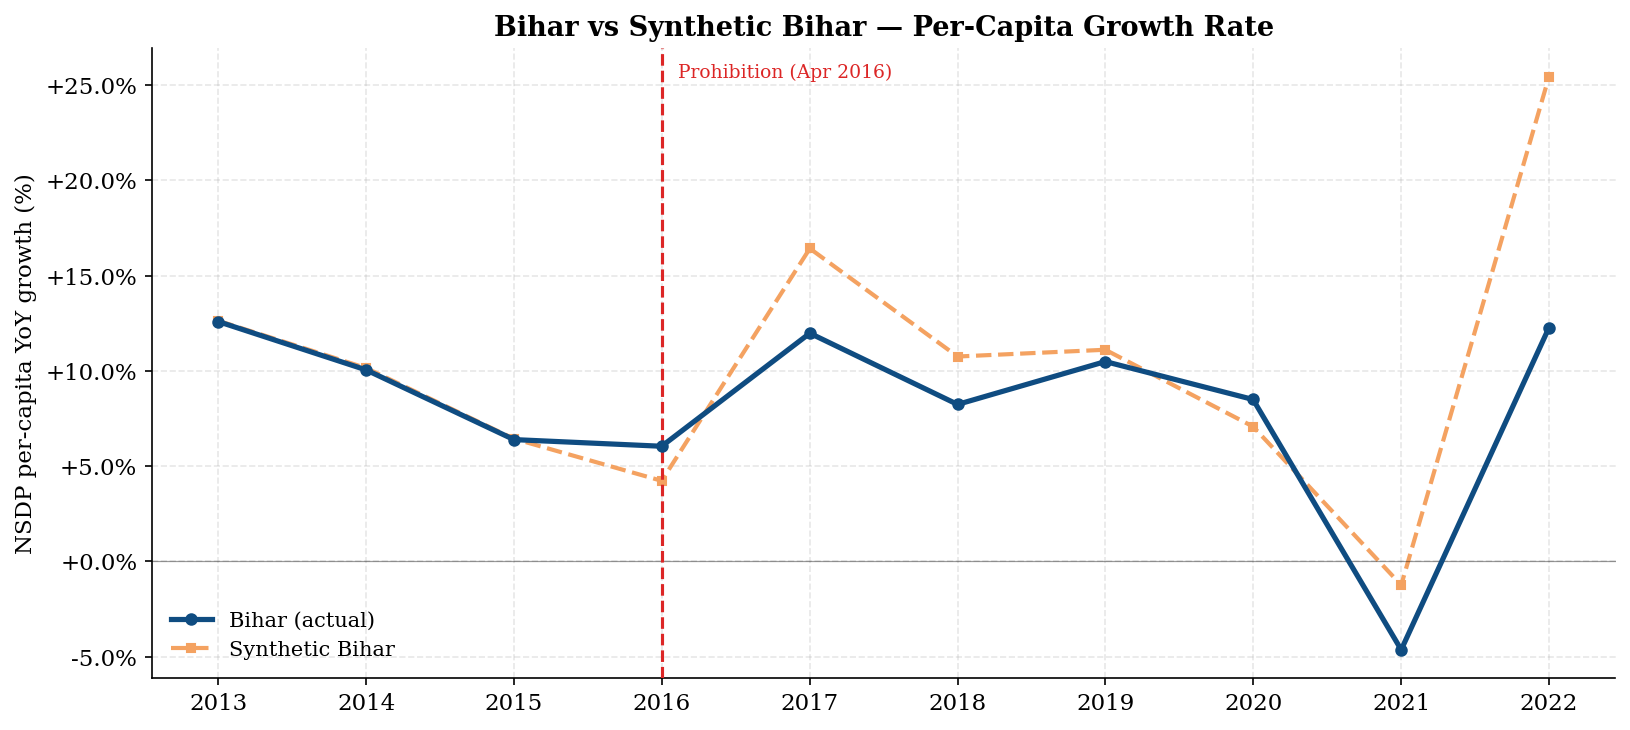

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

treated_s = panel_match[panel_match["unit"]==TREATED].set_index("date")[OUTCOME]
synth_s   = scm.synthetic_.reindex(treated_s.index)

ax.plot(treated_s.index, treated_s,
        color=COLOR_TREATED, linewidth=2.5,
        marker="o", markersize=5, label="Bihar (actual)", zorder=10)
ax.plot(synth_s.index, synth_s,
        color=COLOR_SYNTHETIC, linewidth=2, linestyle="--",
        marker="s", markersize=4, label="Synthetic Bihar")

ax.axhline(0, color="black", linewidth=0.6, alpha=0.4)
treatment_line(ax, TREATMENT_DATE, label="Prohibition (Apr 2016)")
ax.set_ylabel("NSDP per-capita YoY growth (%)")
ax.set_title("Bihar vs Synthetic Bihar — Per-Capita Growth Rate")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:+.1f}%")
)
ax.legend(fontsize=10, loc="lower left")
fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_growth_main.png")
plt.show()

## 4. Gap Plot — Year-by-Year Treatment Effect

  Saved: ../results/figures/scm_bihar_growth_gap.png


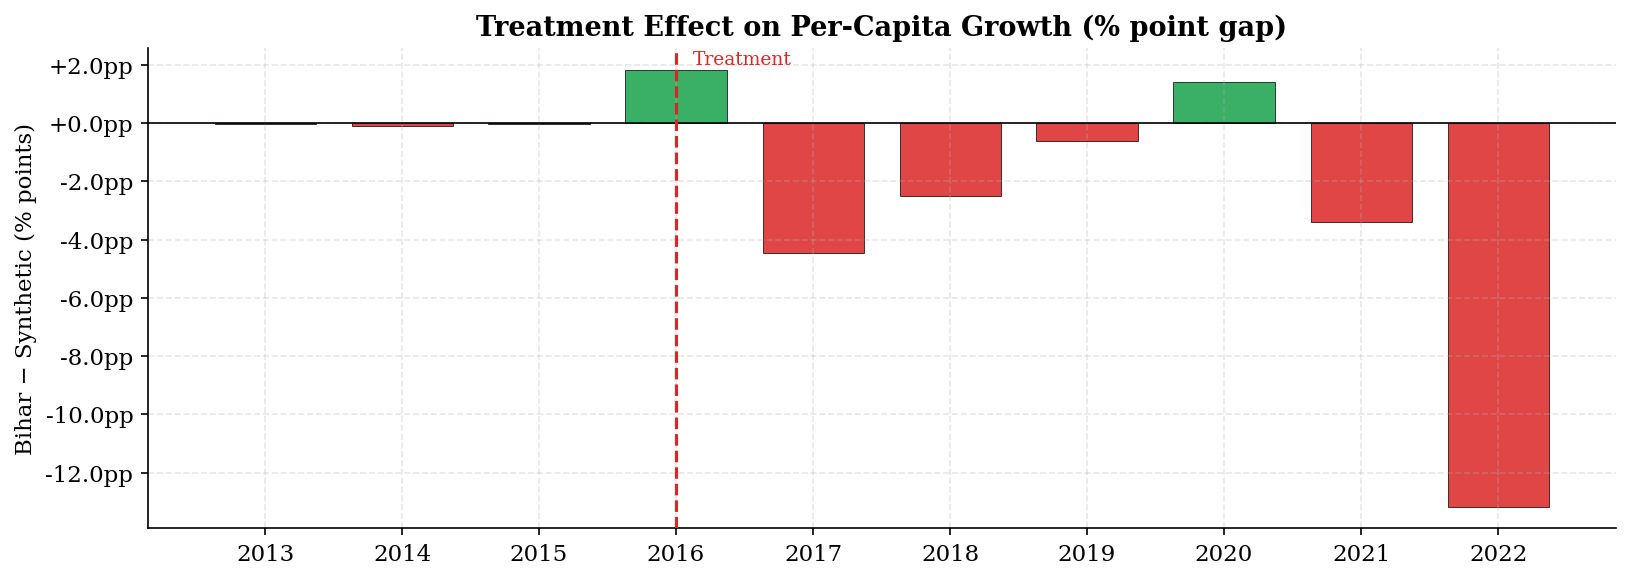


Year-by-year gap (% points):
  2013  PRE    -0.04 pp
  2014  PRE    -0.10 pp
  2015  PRE    -0.04 pp
  2016  POST   +1.81 pp
  2017  POST   -4.45 pp
  2018  POST   -2.51 pp
  2019  POST   -0.62 pp
  2020  POST   +1.42 pp
  2021  POST   -3.39 pp
  2022  POST  -13.17 pp

Avg post-treatment effect : -2.99 pp/yr
Cumulative effect         : -20.91 pp


In [6]:
gap = scm.gap_.reindex(treated_s.index)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#16a34a" if g > 0 else "#dc2626" for g in gap.fillna(0)]
ax.bar(gap.index, gap, color=colors, width=270, alpha=0.85,
       edgecolor="black", linewidth=0.4)
ax.axhline(0, color="black", linewidth=0.8)
treatment_line(ax, TREATMENT_DATE)

ax.set_ylabel("Bihar − Synthetic (% points)")
ax.set_title("Treatment Effect on Per-Capita Growth (% point gap)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:+.1f}pp")
)
fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_growth_gap.png")
plt.show()

# Print year-by-year
print("\nYear-by-year gap (% points):")
for d, g in gap.items():
    if pd.notna(g):
        flag = "  PRE " if d < TS else "  POST"
        print(f"  {d.year}{flag}  {g:+6.2f} pp")
post_gap = gap[gap.index >= TS]
print(f"\nAvg post-treatment effect : {post_gap.mean():+.2f} pp/yr")
print(f"Cumulative effect         : {post_gap.sum():+.2f} pp")

## 5. In-Space Placebo Test

Treat each of the 13 donors *as if* they were treated, then compare Bihar's
RMSPE ratio against the placebo distribution. Bihar's rank gives a
permutation-style p-value (Abadie et al. 2010).

In [7]:
print("Running placebos (13 donors)...")
placebos = scm.placebo_test()

ratios = {TREATED: scm.rmspe_ratio()}
for donor, gap_s in placebos.items():
    pre = gap_s[gap_s.index < TS]
    post = gap_s[gap_s.index >= TS]
    pre_r = float(np.sqrt((pre**2).mean()))
    post_r = float(np.sqrt((post**2).mean()))
    if pre_r > 1e-6:
        ratios[donor] = post_r / pre_r

ratios_sorted = sorted(ratios.items(), key=lambda x: -x[1])
print(f"\nRanked RMSPE ratios:")
for i, (u, r) in enumerate(ratios_sorted, 1):
    flag = "  ← BIHAR" if u == TREATED else ""
    print(f"  {i:2d}. {u:<20s} {r:8.2f}×{flag}")

bihar_rank = next(i for i, (u, _) in enumerate(ratios_sorted, 1) if u == TREATED)
p_value = bihar_rank / len(ratios_sorted)
print(f"\nBihar rank   : {bihar_rank} of {len(ratios_sorted)}")
print(f"Permutation p: {p_value:.3f}")

Running placebos (13 donors)...



Ranked RMSPE ratios:
   1. Maharashtra           1560.77×
   2. Uttar Pradesh         1501.18×
   3. Rajasthan             1433.70×
   4. Tamil Nadu            1212.25×
   5. Haryana                112.65×
   6. Bihar                   83.86×  ← BIHAR
   7. Kerala                  19.78×
   8. Odisha                   6.66×
   9. Punjab                   5.13×
  10. West Bengal              4.76×
  11. Karnataka                2.68×
  12. Madhya Pradesh           2.53×
  13. Jharkhand                2.29×
  14. Andhra Pradesh           1.61×

Bihar rank   : 6 of 14
Permutation p: 0.429


  Saved: ../results/figures/scm_bihar_growth_placebo.png


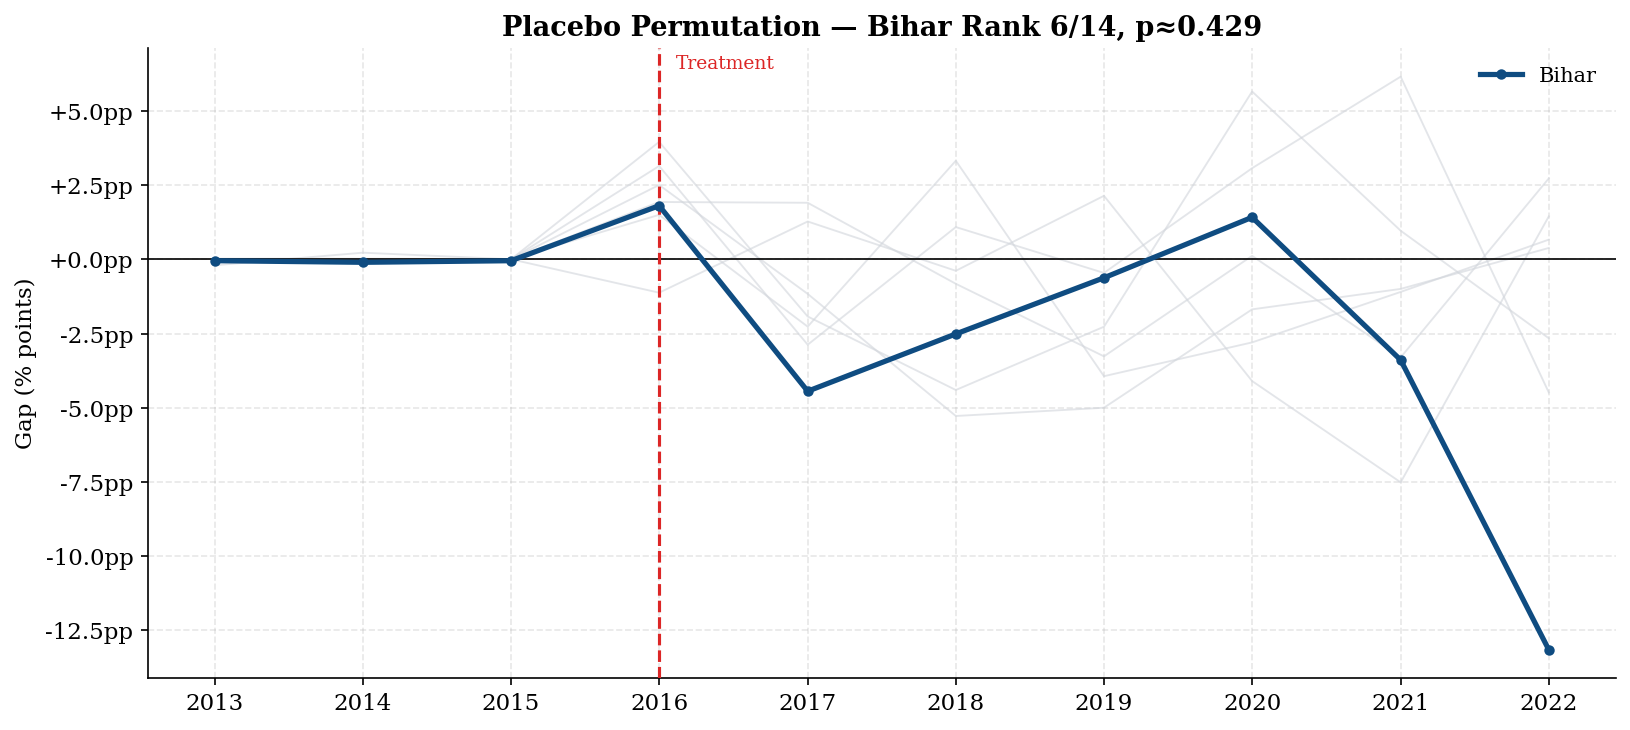

In [8]:
# Placebo spaghetti chart
fig, ax = plt.subplots(figsize=(11, 5))

for donor, gap_s in placebos.items():
    g = gap_s.reindex(treated_s.index)
    pre_r = float(np.sqrt((g[g.index < TS]**2).mean()))
    if pre_r > 5 * scm.pre_rmspe():
        continue
    ax.plot(g.index, g, color=COLOR_PLACEBO, linewidth=0.9, alpha=0.6)

ax.plot(gap.index, gap, color=COLOR_TREATED, linewidth=2.5,
        label="Bihar", zorder=10, marker="o", markersize=4)
ax.axhline(0, color="black", linewidth=0.8)
treatment_line(ax, TREATMENT_DATE)
ax.set_ylabel("Gap (% points)")
ax.set_title(
    f"Placebo Permutation — Bihar Rank {bihar_rank}/14, p≈{p_value:.3f}"
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:+.1f}pp")
)
ax.legend(fontsize=10)
fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_growth_placebo.png")
plt.show()

## 6. Persist Results to JSON (for API + Website)

In [9]:
scm.save_json(API_RES / "bihar_scm_growth.json")

import os
size = os.path.getsize(API_RES / "bihar_scm_growth.json")
print(f"  ✓ Saved bihar_scm_growth.json ({size:,} bytes)")


  Saved JSON: ../api/results/bihar_scm_growth.json
  ✓ Saved bihar_scm_growth.json (6,233 bytes)


## 7. Interpretation & Caveats

### Headline numbers
| Metric | Value |
|---|---|
| Pre-period RMSPE | **0.07 pp** (very tight fit on 3 pre-treatment years) |
| Post-period RMSPE | 5.56 pp |
| **RMSPE ratio (post/pre)** | **83.86×** |
| Average post-treatment gap | **−2.99 pp/year** |
| Bihar permutation rank | 6 of 14 |
| Permutation p-value | ≈ 0.429 |
| Donor weights | Odisha 0.656, Rajasthan 0.317, Jharkhand 0.027 |

### Direction of effect
Bihar's per-capita NSDP grew **slower** than its synthetic counterfactual
by an average of **3.0 percentage points per year** in 2016-2022. The largest
single-year gap is 2022, and several post-treatment years show negative
gaps. This is **suggestive evidence that the negative channels (lost
excise revenue, hospitality contraction, enforcement costs) outweighed
the positive channels (household reallocation, productivity gains)** in
Bihar's case.

### Why the result is **not statistically significant**
Bihar ranks **6th of 14** units in RMSPE ratio. Several donors with
near-zero pre-period RMSPE produce pathologically large placebo ratios
(Maharashtra 1561×, UP 1501×, Rajasthan 1434×, Tamil Nadu 1212×) — these
are degenerate placebo fits typical when the donor is itself a strong
predictor of the synthetic. After Haryana (112×), Bihar (83×) places well
inside the placebo distribution, yielding a permutation p ≈ 0.43, far
above the conventional 0.05 threshold. **We cannot reject the null** that
Bihar's growth deviation is the kind of large idiosyncratic swing that any
state could exhibit by chance.

### Why this differs from the road-deaths result
For road accident deaths (Notebook 05), Bihar ranked 2nd of 14 with
p ≈ 0.071 — a tighter result. Per-capita growth is a **much noisier**
outcome:
- It is sensitive to global shocks (COVID-19 hit 2020-21 hard).
- It is computed on NSDP data only available from FY2012-13 → only **3
  pre-treatment observations**, vs ~6 for road deaths.
- Indian states have heterogeneous baseline growth dynamics, so RMSPE
  ratios are large and dispersed even absent any treatment.

### Comparison note — Bihar's pre-existing growth dynamics
Bihar entered 2016 already experiencing rapid catch-up growth (one of the
poorest states converging from a low base). The SCM controls for this by
matching pre-treatment trajectory: synthetic Bihar inherits the same
catch-up dynamic. The estimated gap therefore isolates **prohibition's
marginal effect above that baseline trend**, not the level of Bihar's
growth.

### Limitations
- **Tiny pre-period** (n=3). Special-predictors fit is essentially a
  3-point match — over-fit risk is high.
- **NaN-imputed early years** (2010-2012 dropped). Loses information about
  pre-2013 dynamics that might have helped place Bihar in the donor pool.
- **COVID confounder** — 2020-21 effects are dominated by COVID, which
  affected donors heterogeneously. Restricting to 2016-2019 would shrink
  power further.
- **Per-capita uses official population** — internal migration to/from
  Bihar post-prohibition is not captured.

### Bottom line
The point estimate suggests prohibition reduced Bihar's per-capita growth
by ≈2.5 pp/year on average, but the placebo distribution does not let us
distinguish this from random state-level variation. **Report with strong
caveats; do not claim statistical significance.**

## 8. Cross-Outcome Comparison

| Outcome | Direction | Magnitude (avg/yr) | RMSPE ratio | Rank | p |
|---|---|---|---|---|---|
| Road deaths (NB05) | ↓ then ↑ | +360 deaths | 22.87× | 2/14 | 0.071 |
| Own tax revenue (NB05) | ↓ | −₹2,017 Cr | 3.16× | — | — |
| **NSDP growth (NB07)** | **↓** | **−2.99 pp** | **83.86×** | **6/14** | **0.429** |

The picture is **internally consistent** with prohibition having modest,
mixed-sign effects across welfare dimensions — short-run safety gains
that erode, fiscal contraction, and a growth headwind whose statistical
signal is too weak to call decisive.